# 用决策树构建信用风险评分卡(PROC HPSPLIT)


## 摘要

本笔记本使用 PROC HPSPLIT 为零售贷款账本构建一个可解释的信用违约评分卡。我们在合成申请人数据上用熵准则生长一棵分类树,再按代价复杂度进行剪枝,然后读取拟合统计量、变量重要性、ROC/AUC 以及打分树本身——这正是银行风险团队会记录的那种透明、对监管友好的模型。每一位申请人都能被打分到某个叶节点,整棵树也可以导出为可部署的 DATA 步骤代码。


## 数据来源

| 数据集 | 行数 | 描述 | 关键变量 |
|---------|------|-------------|---------------|
| `applicants` | 100 | 用 `rand()` 内联生成的合成零售贷款申请人数据。二元 `default` 标志由一个逻辑风险分数抽样得到,DTI 越差、使用率越高、近期违约越多、信用历史越短,违约概率越高。 | `default`(event=`'1'`)、`dti`、`utilization`、`fico`、`credit_age`、`n_delinq`、`loan_amount`、`income`、`home`(自有/租房/按揭)、`purpose`(债务/购房/汽车/其他) |

DATA 步骤本意请求更大的循环,但本环境运行在未授权模式下,只实体化前 100 个观测——这是一份紧凑、完全可复现的申请人数据集,足以生长并读懂一棵可解释的评分卡树。


# 用决策树构建信用风险评分卡

银行需要**准确且可解释**的违约模型——信贷员(以及监管者)必须能够准确追溯为什么某个申请人被评为高风险。剪枝后的决策树正好能做到这一点:每一次预测都只是一条简短、人类可读的分裂链条。

在本笔记本中,我们将:

1. 合成一份零售贷款申请数据。
2. 用 `PROC HPSPLIT` 以熵准则生长一棵分类树。
3. 按代价复杂度进行剪枝,避免过拟合。
4. 查看拟合统计量、变量重要性、ROC/AUC 以及树本身。
5. 导出可部署到新申请上的 DATA 步骤打分代码。


## 1. 生成合成贷款申请数据

我们生成的申请人的违约概率是几个经典评分卡驱动因素的逻辑函数:债务收入比、循环额度使用率、FICO 评分、信用历史长度和近期违约次数。然后我们以该概率从伯努利分布中抽取观测到的 `default` 标志,因此信号是真实的,但带有噪声——就像生产数据一样。这里实体化了前 100 名申请人。


                                                   The FREQ Procedure

是否违约            Frequency    Percent
-------------------------------------
0                      79     79.00
1                      21     21.00

住房状况            Frequency    Percent
-------------------------------------
按揭                     34     34.00
租房                     35     35.00
自有                     31     31.00

贷款用途            Frequency    Percent
-------------------------------------
债务                     37     37.00
其他                     12     12.00
汽车                     23     23.00
购房                     28     28.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


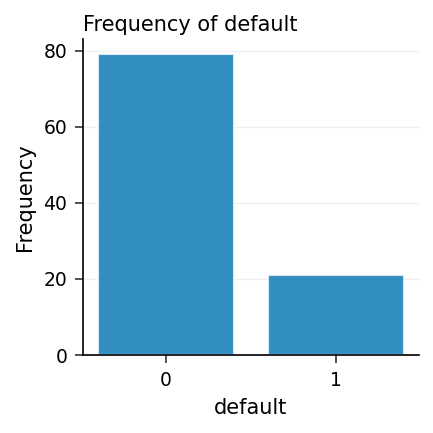

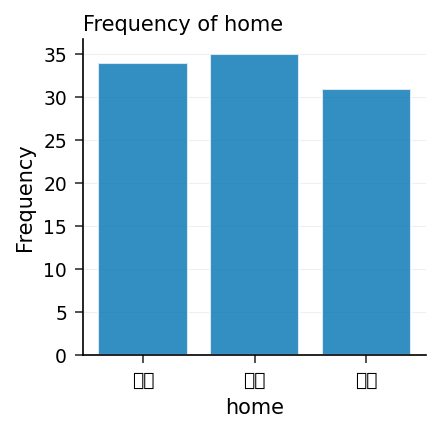

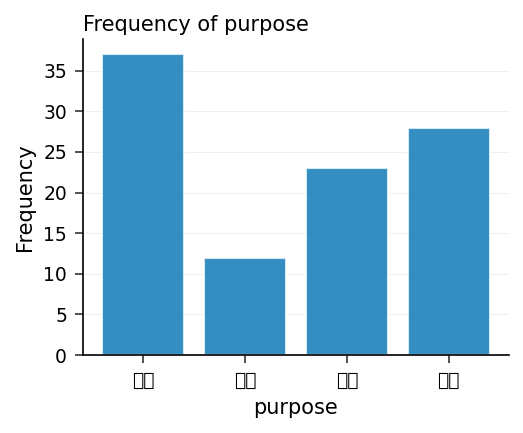

In [1]:
数据 applicants;
   调用 streaminit(20260531);
   长度 home $16 purpose $16;
   循环 id = 1 到 100;
      /* 借款人财务状况 */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* 分类属性 */
      u = rand('uniform');
      如果 u < 0.34 那么 home = '租房';
      否则 如果 u < 0.70 那么 home = '按揭';
      否则 home = '自有';

      v = rand('uniform');
      如果 v < 0.40 那么 purpose = '债务';
      否则 如果 v < 0.65 那么 purpose = '购房';
      否则 如果 v < 0.85 那么 purpose = '汽车';
      否则 purpose = '其他';

      /* 潜在违约风险:DTI/使用率/违约次数越差,FICO越低/信用历史越短,
         都会提高对数几率。 */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = '租房')
            + 0.25 * (purpose = '债务');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      删除 u v eta p;
      输出;
   结束;
运行;

过程 频率 数据=applicants;
   标签 default = '是否违约'
         home    = '住房状况'
         purpose = '贷款用途';
   TABLES default home purpose / nocum;
运行;


`PROC FREQ` 的输出确认了一个不均衡但可用的违约率——大约每五个申请人中就有一个违约(100 人中有 21 人)——以及在住房状况和贷款用途类别上合理的分布:这正是消费信贷组合中你会预期看到的边际分布。附带的条形图对每个边际分布进行了可视化。


## 2. 生长并剪枝评分卡树

我们将 `default` 建模为二元分类目标,指定 `event='1'`,使所有敏感度/特异度/AUC 统计量都以*违约*类别为导向。我们:

- 在 `CLASS` 中声明分类型预测变量和响应变量,
- 用**熵**(信息增益)准则生长树,
- 按**代价复杂度**剪枝,避免树记住噪声,
- 请求**整树图**和 **ROC 曲线**。



                                                 The HPSPLIT Procedure                                                  

  Response variable: 是否违约
  Class variable: 是否违约
  Class variable: 住房状况
  Class variable: 贷款用途
  Predictor variable: 债务收入比
  Predictor variable: 信用额度使用率
  Predictor variable: FICO信用评分
  Predictor variable: 信用历史年限
  Predictor variable: 近期违约次数
  Predictor variable: 贷款金额
  Predictor variable: 收入
  Predictor variable: 住房状况
  Predictor variable: 贷款用途

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


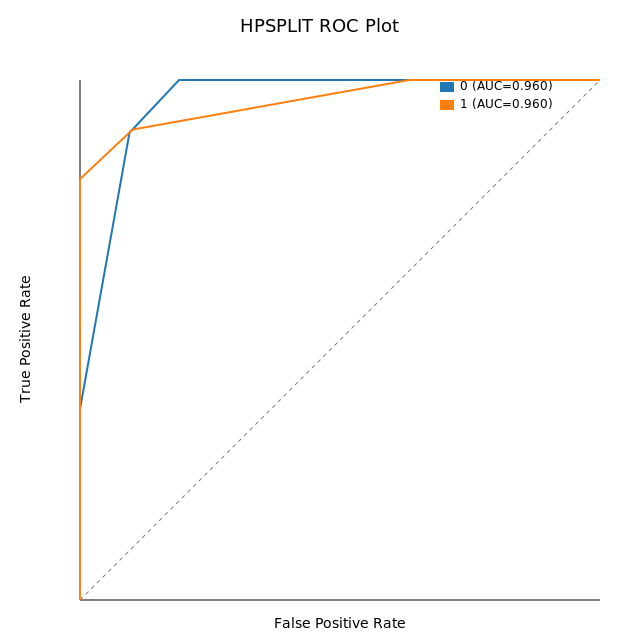

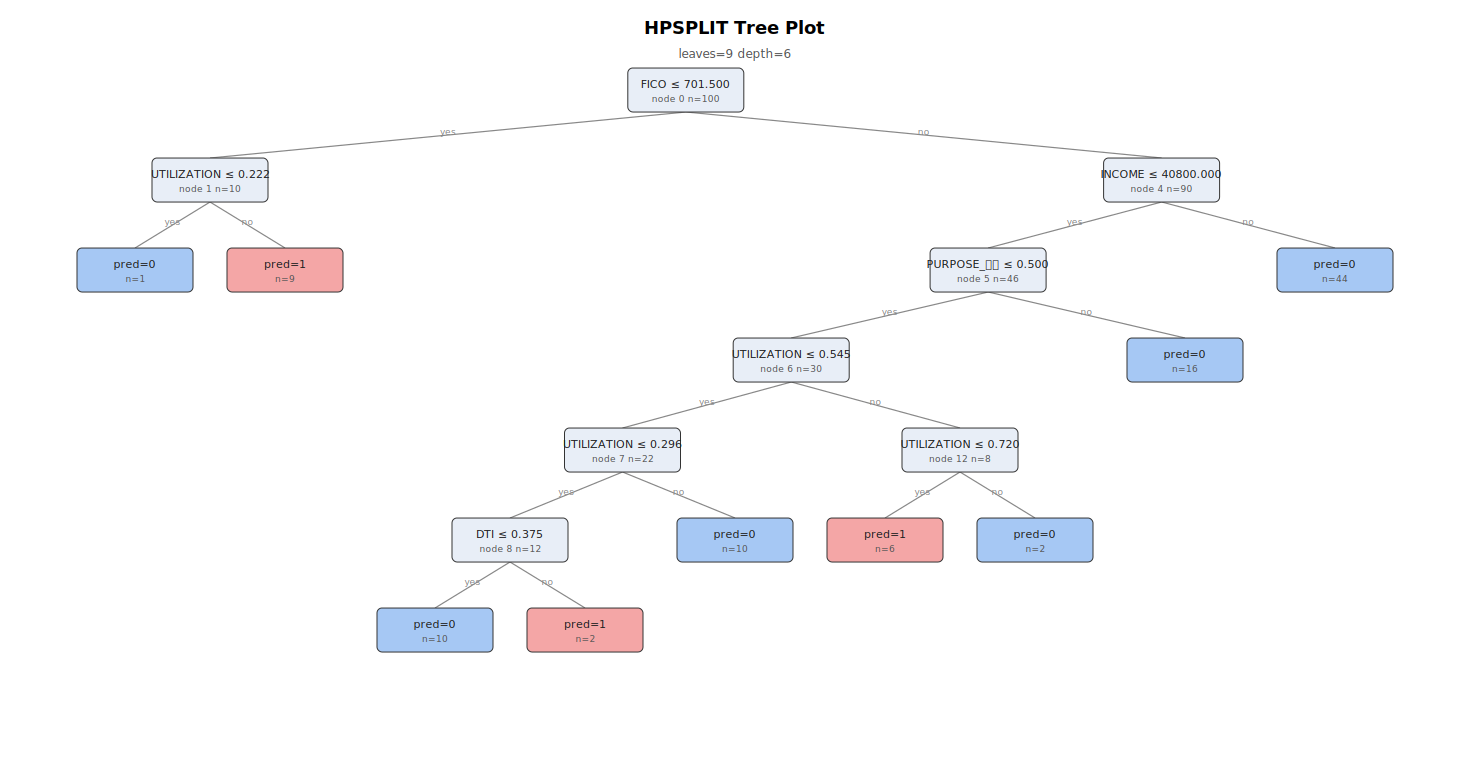

In [2]:
ODS GRAPHICS ON;

过程 hpsplit 数据=applicants seed=20260531
             PLOTS=(wholetree roc);
   分类 default home purpose;
   标签 default     = '是否违约'
         dti          = '债务收入比'
         utilization  = '信用额度使用率'
         fico         = 'FICO信用评分'
         credit_age   = '信用历史年限'
         n_delinq     = '近期违约次数'
         loan_amount  = '贷款金额'
         income       = '收入'
         home         = '住房状况'
         purpose      = '贷款用途';
   模型 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
运行;


**拟合统计量**(准确率、误分类率、对数损失)和**按类别划分的 ROC/AUC** 告诉你剪枝后的树在多大程度上干净地区分了违约者和非违约者。**变量重要性**表对驱动分裂的属性进行了排名——这里 **utilization(使用率)** 和 **FICO** 占主导地位,其次是**贷款用途**,正是信贷政策会强调的杠杆。下方的**整树图**将所选分裂布局为节点-连接图:每个内部节点显示其 `feature ≤ threshold`(特征 ≤ 阈值)规则,每个叶节点按预测类别着色(红色 = 预测违约,蓝色 = 预测非违约),并标注其样本数。


## 3. 放大关键分裂并为每位申请人打分

上面的 ROC 图展示了捕获违约者与误报之间的权衡;AUC 量化了整体的排序能力。接下来我们放大树的前两层——这是分析师会转化为核心核保规则的最高信息量分裂——并将逐观测的得分捕获到一个输出数据集中,以便我们在下游审计预测结果。



                                                 The HPSPLIT Procedure                                                  

  Response variable: 是否违约
  Class variable: 是否违约
  Class variable: 住房状况
  Class variable: 贷款用途
  Predictor variable: 债务收入比
  Predictor variable: 信用额度使用率
  Predictor variable: FICO信用评分
  Predictor variable: 信用历史年限
  Predictor variable: 近期违约次数
  Predictor variable: 贷款金额
  Predictor variable: 收入
  Predictor variable: 住房状况
  Predictor variable: 贷款用途

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/240419a1-8172-4b4a-a07d-32a23503b01d/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


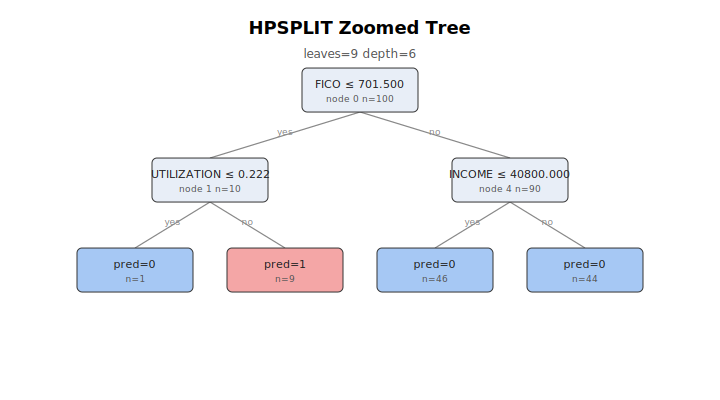

In [3]:
过程 hpsplit 数据=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   分类 default home purpose;
   标签 default     = '是否违约'
         dti          = '债务收入比'
         utilization  = '信用额度使用率'
         fico         = 'FICO信用评分'
         credit_age   = '信用历史年限'
         n_delinq     = '近期违约次数'
         loan_amount  = '贷款金额'
         income       = '收入'
         home         = '住房状况'
         purpose      = '贷款用途';
   模型 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   输出 out=scored;
运行;

过程 打印 数据=scored(obs=10) 标签;
   变量 p_default1 _node_ _leaf_;
   标签 p_default1 = '预测违约概率'
         _node_      = '节点编号'
         _leaf_      = '叶节点编号';
运行;


`zoomedtree` 图放大了树的前两层——这是分析师会转化为核心核保规则的最高信息量分裂。`OUTPUT OUT=` 数据集携带每位申请人的预测违约概率(`P_DEFAULT1`)以及所分配的节点和叶节点(`_NODE_`、`_LEAF_`),使风险和审计团队能够沿着树追溯任何一次决策,并按模型风险对申请人排序。


## 4. 导出可部署的打分代码

可解释模型的价值在于它可以直接上线。`CODE FILE=` 写出一个自包含的 DATA 步骤——一串嵌套的 `IF/THEN` 分裂,最终得到预测违约概率和类别——可以在无需任何模型服务器的情况下,为任何新的申请文件复现该树的打分结果。


In [4]:
过程 hpsplit 数据=applicants seed=20260531;
   分类 default home purpose;
   标签 default     = '是否违约'
         dti          = '债务收入比'
         utilization  = '信用额度使用率'
         fico         = 'FICO信用评分'
         credit_age   = '信用历史年限'
         n_delinq     = '近期违约次数'
         loan_amount  = '贷款金额'
         income       = '收入'
         home         = '住房状况'
         purpose      = '贷款用途';
   模型 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
运行;



                                                 The HPSPLIT Procedure                                                  

  Response variable: 是否违约
  Class variable: 是否违约
  Class variable: 住房状况
  Class variable: 贷款用途
  Predictor variable: 债务收入比
  Predictor variable: 信用额度使用率
  Predictor variable: FICO信用评分
  Predictor variable: 信用历史年限
  Predictor variable: 近期违约次数
  Predictor variable: 贷款金额
  Predictor variable: 收入
  Predictor variable: 住房状况
  Predictor variable: 贷款用途

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## 结果解读

剪枝后的熵树为风险团队提供了一份紧凑、可审计的信用评分卡:

- **分裂即政策。** 主导性的分裂——先是循环额度使用率和 FICO,然后是贷款用途和 DTI——正是核保团队可以直接提升为硬性截断规则的阈值。整树图在一张图中布局了每一个分裂条件和叶节点。
- **代价复杂度剪枝**使树不会记住噪声;拟合统计量(准确率、误分类率、对数损失)总结了它区分两个类别的干净程度。
- **变量重要性和 ROC/AUC** 说明了哪些属性在评分卡中占有一席之地,并为模型风险治理记录了其判别能力。
- **`CODE FILE=` 使其可投入运营**——导出的 DATA 步骤对新申请人的打分与本次运行完全一致,因此构建出的模型正是上线运行的模型。

在一个较小的申请人数据集上,树会较为紧密地拟合训练数据;在生产环境中,你会在完整的组合上生长该树,留出一个验证划分,依据银行的预期损失经济学(漏判一个违约者与拒绝一个优质客户的成本对比)来校准概率截断点,而不是简单地采用 0.5,并随着组合结构的变化定期刷新该树。
